# Gen 2.1 SVM Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import joblib

Optimal Parameters: {'C': 0.5, 'gamma': 1, 'kernel': 'rbf'}
Accuracy of the current model: 46.15384615384615


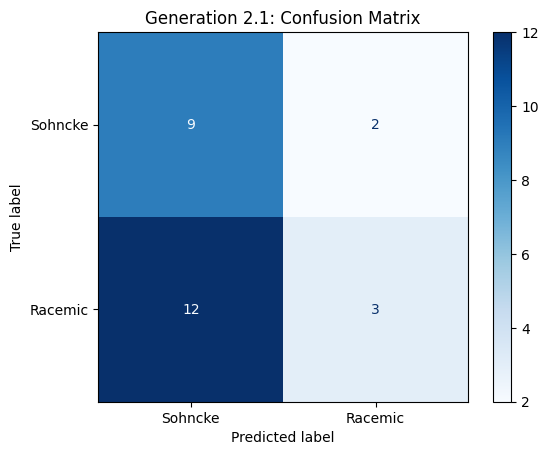

In [3]:
list = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list)

# Balancing the dataset
df_target_0 = df[df['Target'] == 0.0] # DataFrame where target = 0.0
df_target_1 = df[df['Target'] == 1.0] # DataFrame where target = 1.0
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

# Identify the DataFrame with fewer rows
if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

scaled_larger_df = larger_df.sample(n = smaller_rows) # Randomly sample from the larger DataFrame to match the number of rows in the smaller DataFrame
balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0) # Concatenate the two DataFrames
shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True) # Shuffle the DataFrames

shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode']) # Cleaning the database and getting rid of any rows that aren't 'float64'

feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target']) # Creating a new dataframe with just the sohncke/racemic answers

X = np.asarray(feature_df) # Putting all the descriptor information in an array
y = np.asarray(shuffled_balanced_cleaned_df['Target']) # Putting all the target information in an array

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30) # Generating the training and testing data with a 70/30 split

#Trying to obtain the most optimal parameters for the model
param_grid = [
    {'C': [0.5, 1, 10, 100],
     'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
     'kernel': ['rbf', 'linear', 'poly']}
]

optimal_params = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=0
)

optimal_params.fit(X_train, y_train)
print(f'Optimal Parameters: {optimal_params.best_params_}') # Printing out the optimal conditions

classifier = optimal_params.best_estimator_ # Storing the optimal conditions
classifier.fit(X_train, y_train) # Using the optimial conditions for the model

y_predict = classifier.predict(X_test) # Predicting sohncke/racemic with the new model

print("Accuracy of the current model:",metrics.accuracy_score(y_test, y_predict)*100) # Printing out the accuracy

# Outputting the confusion matrix
ConfusionMatrixDisplay.from_estimator(
    classifier, 
    X_test, 
    y_test, 
    display_labels=["Sohncke", "Racemic"],
    cmap=plt.cm.Blues,
    values_format='d'
);
plt.title('Generation 2.1: Confusion Matrix');

---
# Obtaining The Best Accuracy with a SVC Model Gen 2.1

The average of averages accuracy over 500 runs is: 53.90%
Parameters used: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}


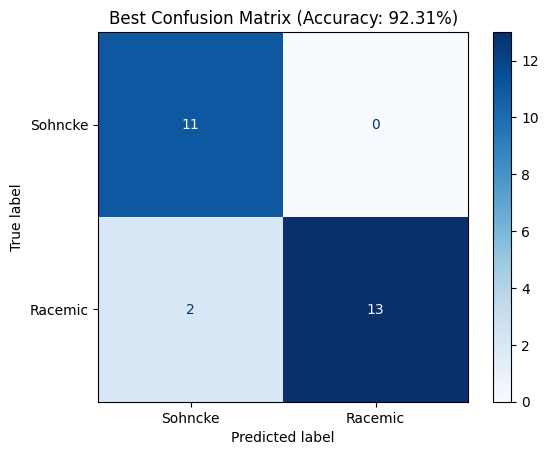

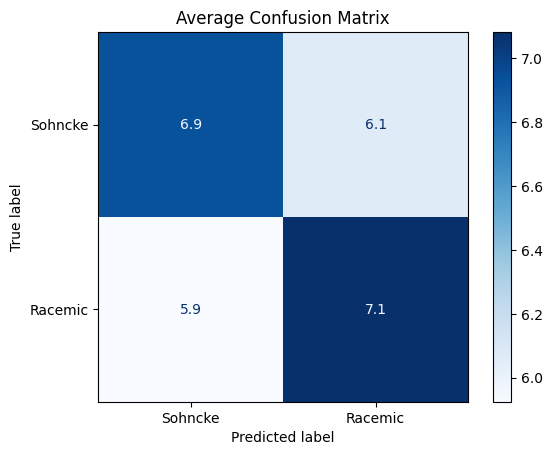

Best model saved to best_svc_model_gen_2_1.pkl


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

# Load data
list_path = r'filtered and normalised all descriptor data.csv'
df = pd.read_csv(list_path)

# Split data based on the target column
df_target_0 = df[df['Target'] == 0.0]
df_target_1 = df[df['Target'] == 1.0]
rows_df_target_0 = df_target_0.shape[0]
rows_df_target_1 = df_target_1.shape[0]

if rows_df_target_0 < rows_df_target_1:
    smaller_df = df_target_0
    larger_df = df_target_1
    smaller_rows = rows_df_target_0
else:
    smaller_df = df_target_1
    larger_df = df_target_0
    smaller_rows = rows_df_target_1

n_repeats = 500  # Number of times to run the experiment
n_iterations = 200  # Number of iterations per experiment
average_accuracies = []  # To store the average accuracy of each experiment

# Set fixed parameters for the SVC model
fixed_params = {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}

# Initialize variables to store the best accuracy, confusion matrix, and accumulator for average confusion matrix
best_accuracy = 0
best_confusion_matrix = None
best_model = None  # To store the best model
confusion_matrix_accumulator = np.zeros((2, 2))  # Assuming binary classification (2x2 confusion matrix)

for _ in range(n_repeats):
    accuracy_list = []

    for _ in range(n_iterations):
        scaled_larger_df = larger_df.sample(n=smaller_rows)
        balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0)
        shuffled_balanced_df = balanced_df.sample(frac=1).reset_index(drop=True)
        shuffled_balanced_cleaned_df = shuffled_balanced_df.drop(columns=['Point group', 'Refcode'])
        feature_df = shuffled_balanced_cleaned_df.drop(columns=['Target'])
        X = np.asarray(feature_df)
        y = np.asarray(shuffled_balanced_cleaned_df['Target'])
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

        # Initialize the SVC classifier with fixed parameters
        classifier = SVC(**fixed_params)
        classifier.fit(X_train, y_train)

        y_predict = classifier.predict(X_test)
        accuracy = metrics.accuracy_score(y_test, y_predict) * 100
        accuracy_list.append(accuracy)

        # Update best accuracy and confusion matrix if the current accuracy is the best
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_confusion_matrix = metrics.confusion_matrix(y_test, y_predict)
            best_model = classifier  # Save the best model

        # Accumulate confusion matrices
        confusion_matrix_accumulator += metrics.confusion_matrix(y_test, y_predict)

    # Record the average accuracy for this experiment
    average_accuracy = np.mean(accuracy_list)
    average_accuracies.append(average_accuracy)

# Print the overall average accuracy
overall_average_accuracy = np.mean(average_accuracies)
print(f'The average of averages accuracy over {n_repeats} runs is: {overall_average_accuracy:.2f}%')

# Print the fixed parameters used
print(f'Parameters used: {fixed_params}')

# Print the best confusion matrix with custom labels and color
if best_confusion_matrix is not None:
    disp = ConfusionMatrixDisplay(confusion_matrix=best_confusion_matrix, display_labels=['Sohncke', 'Racemic'])
    disp.plot(cmap='Blues')  # Set the color to blue
    plt.title(f'Best Confusion Matrix (Accuracy: {best_accuracy:.2f}%)')
    plt.show()

# Compute and print the average confusion matrix
average_confusion_matrix = confusion_matrix_accumulator / (n_repeats * n_iterations)
disp_avg = ConfusionMatrixDisplay(confusion_matrix=average_confusion_matrix, display_labels=['Sohncke', 'Racemic'])
disp_avg.plot(cmap='Blues')  # Set the color to blue
plt.title(f'Average Confusion Matrix')
plt.show()

# Save the best model
if best_model is not None:
    joblib.dump(best_model, 'best_svc_model_gen_2_1.pkl')
    print('Best model saved to best_svc_model_gen_2_1.pkl')
else:
    print('No model to save.')

---

# Average of 100 runs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV
import pickle  # Import pickle to save the model

# Path to the CSV file
list_path = r'filtered and normalised all descriptor data.csv'

# Number of iterations
iterations = 100

# Initialize variables to store results
accuracies = []
confusion_matrices = []
models = []  # List to store models

# Set up the parameter grid for GridSearchCV
param_grid = [
        {'C': [0.5, 1, 10, 100],
         'gamma': ['scale', 1, 0.1, 0.01, 0.001, 0.0001],
         'kernel': ['rbf', 'linear', 'poly']}
    ]

optimal_params = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', verbose=0)
classifier = optimal_params.best_estimator_

for _ in range(iterations):
    # Load the data
    df = pd.read_csv(list_path)

    # Balance the dataset
    df_target_0 = df[df['Target'] == 0.0]
    df_target_1 = df[df['Target'] == 1.0]
    
    if len(df_target_0) < len(df_target_1):
        smaller_df = df_target_0
        larger_df = df_target_1
    else:
        smaller_df = df_target_1
        larger_df = df_target_0

    scaled_larger_df = larger_df.sample(n=len(smaller_df))  # Sample to balance the dataset
    balanced_df = pd.concat([smaller_df, scaled_larger_df], axis=0).sample(frac=1).reset_index(drop=True)

    # Clean the data
    cleaned_df = balanced_df.drop(columns=['Point group', 'Refcode'])

    # Separate features and target
    X = np.asarray(cleaned_df.drop(columns=['Target']))
    y = np.asarray(cleaned_df['Target'])

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

    # Perform grid search
    
    optimal_params.fit(X_train, y_train)

    # Train the classifier with the best parameters
    
    classifier.fit(X_train, y_train)

    # Make predictions
    y_predict = classifier.predict(X_test)

    # Calculate accuracy
    accuracy = metrics.accuracy_score(y_test, y_predict) * 100
    accuracies.append(accuracy)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_predict)
    confusion_matrices.append(cm)
    
    # Store the model
    models.append(classifier)

    print(f'Run {_+1} completed with accuracy: {accuracy}')

# Calculate the average accuracy
average_accuracy = np.mean(accuracies)

# Find the best model (highest accuracy)
best_accuracy_index = np.argmax(accuracies)
best_model = models[best_accuracy_index]
best_confusion_matrix = confusion_matrices[best_accuracy_index]
best_accuracy = accuracies[best_accuracy_index]

# Save the best model as a .pkl file using pickle
pkl_file = "best_svm_model.pkl"
with open(pkl_file, 'wb') as file:
    pickle.dump(best_model, file)
print(f"Best model saved as {pkl_file}")

# Calculate the average confusion matrix
average_confusion_matrix = np.mean(confusion_matrices, axis=0)

# Display the best confusion matrix
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'SVM Gen 2: Best Confusion Matrix [Accuracy: {best_accuracy:.2f}%]')
plt.show()

# Display the average confusion matrix
ConfusionMatrixDisplay(average_confusion_matrix, display_labels=["Sohncke", "Racemic"]).plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title('SVM Gen 2: Average Confusion Matrix')
plt.show()

# Print the average accuracy
print(f"Average Accuracy over 100 runs: {average_accuracy:.2f}%")


AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'